# AI detection tools evaluation
## Dataset download

In [1]:
from datasets import load_dataset
ds = load_dataset("silentone0725/ai-human-text-detection-v1")

Repo card metadata block was not found. Setting CardData to empty.


In [2]:
ds.save_to_disk("ai_human_text_detection_data")

Saving the dataset (0/1 shards):   0%|          | 0/36744 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7874 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7874 [00:00<?, ? examples/s]

In [3]:
data = ds["train"]

TEXT_COL = "text"
LABEL_COL = "label"

ai_texts = []
human_texts = []

for item in data:

    text = item[TEXT_COL].strip()
    if not text:
        continue
    text = text.strip()
    label = item[LABEL_COL]

    if len(text.split()) < 50:
        continue

    if label == "ai" and len(ai_texts) < 25:
        ai_texts.append(text)
    elif label == "human" and len(human_texts) < 25:
        human_texts.append(text)

    if len(ai_texts) == 25 and len(human_texts) == 25:
        break

def save_to_file(texts, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for i, text in enumerate(texts, start=1):
            f.write(f"{i}\n{text}\n\n")

save_to_file(ai_texts, "tools_test_data/ai_texts.txt")
save_to_file(human_texts, "tools_test_data/human_texts.txt")

## Models inference

In [2]:
from datasets import load_dataset
from transformers import pipeline, GPT2LMHeadModel, GPT2Tokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch
import numpy as np

In [3]:
data = ds["train"].shuffle(seed=42).select(range(200))

TEXT_COL = "text"
LABEL_COL = "label"

detector_base = pipeline(
    "text-classification",
    model="roberta-base-openai-detector",
    truncation=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base-openai-detector
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
y_true_roberta = []
y_pred_base_roberta = []

def map_label(pred_label):
    return 1 if pred_label == "Fake" else 0

for item in data:
    text = item[TEXT_COL]
    true_label = item[LABEL_COL]

    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])

    y_true_roberta.append(true_label)
    y_pred_base_roberta.append(pred_label)

In [5]:
tokenizer_gpt2 = GPT2Tokenizer.from_pretrained("gpt2")
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
model_gpt2.eval()

def compute_perplexity(text):
    encodings = tokenizer_gpt2(text, return_tensors="pt", truncation=True, max_length=512)
    input_ids = encodings.input_ids

    with torch.no_grad():
        outputs = model_gpt2(input_ids, labels=input_ids)
        loss = outputs.loss

    return torch.exp(loss).item()

def perplexity_to_label(ppl, threshold=50):
    return 1 if ppl < threshold else 0

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [6]:
y_pred_ppl = []

for item in data:
    text = item["text"]
    true_label = item["label"]

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)

    y_pred_ppl.append(pred_ppl)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


## Metrics
### RoBERTa

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

def evaluate(name, y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=["human", "ai"]))

    cm = confusion_matrix(y_true, y_pred, labels=["human", "ai"])

    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"\nFalse Positive Rate (FPR): {fpr:.3f}")
    print(f"False Negative Rate (FNR): {fnr:.3f}")

    _, ax = plt.subplots()
    ax.imshow(cm)

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(["human", "ai"])
    ax.set_yticklabels(["human", "ai"])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {name}")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

       human       0.90      0.95      0.93        86
          ai       0.96      0.92      0.94       114

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200


False Positive Rate (FPR): 0.047
False Negative Rate (FNR): 0.079


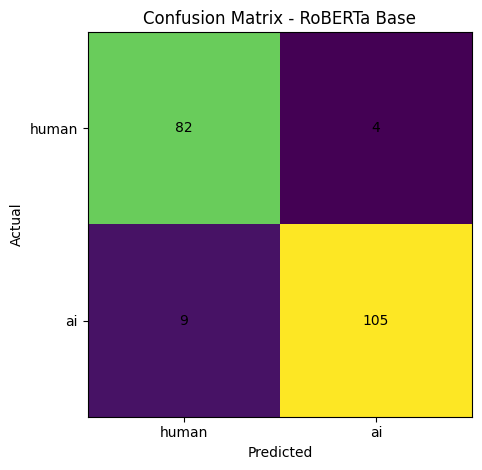

In [24]:
evaluate("RoBERTa Base", y_true_roberta, list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_base_roberta)))

### GPT2

              precision    recall  f1-score   support

       human       1.00      0.50      0.67        86
          ai       0.73      1.00      0.84       114

    accuracy                           0.79       200
   macro avg       0.86      0.75      0.75       200
weighted avg       0.84      0.79      0.77       200


False Positive Rate (FPR): 0.500
False Negative Rate (FNR): 0.000


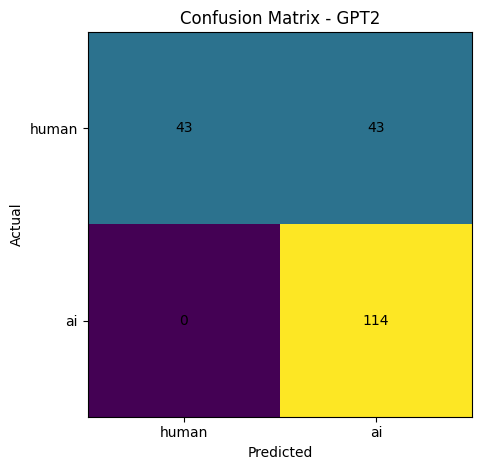

In [25]:
evaluate("GPT2", y_true_roberta, list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_ppl)))

### GPTZero

In [10]:
import re
import pandas as pd

def parse_file(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()

    entries = re.split(r'\n(?=\d+[.,])', content)

    rows = []

    for entry in entries[1:]:
        entry = entry.strip()
        if not entry:
            continue

        try:
            first_comma = entry.find(',')
            second_comma = entry.find(',', first_comma + 1)

            id_ = entry[:first_comma].strip()
            text_and_rest = entry[first_comma+1:]

            last_comma = text_and_rest.rfind(',')
            second_last_comma = text_and_rest.rfind(',', 0, last_comma)

            text = text_and_rest[:second_last_comma].strip().strip('"')
            label = text_and_rest[second_last_comma+1:last_comma].strip()
            score = text_and_rest[last_comma+1:].strip()

            rows.append({
                "id": int(id_),
                "text": text,
                "true_label": label,
                "score": float(score)
            })

        except Exception as e:
            print(f"Skipping malformed entry:\n{entry[:100]}...\nError: {e}\n")

    return pd.DataFrame(rows)


df = parse_file("results/gprzero.csv")

print(df.head())
print(f"Loaded rows: {len(df)}")

   id                                               text true_label  score
0   1  We don't actually know what color dinosaurs li...         ai   0.00
1   2  A ship of the line was a type of warship that ...         ai   1.00
2   3  There are many complex factors that have contr...         ai   0.38
3   4  Elijah McCoy (1844-1929) was an African Americ...         ai   0.81
4   5  It's true that China is a major player in the ...         ai   0.05
Loaded rows: 30


              precision    recall  f1-score   support

       human       0.75      1.00      0.86        15
          ai       1.00      0.67      0.80        15

    accuracy                           0.83        30
   macro avg       0.88      0.83      0.83        30
weighted avg       0.88      0.83      0.83        30


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.333


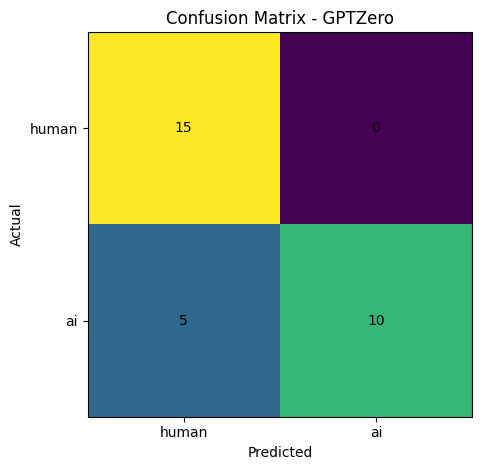

In [26]:
df["pred_label"] = df["score"].apply(lambda x: "ai" if x >= 0.5 else "human")

y_true_gpt = df["true_label"]
y_pred_gpt = df["pred_label"]

evaluate("GPTZero", y_true_gpt, y_pred_gpt)

### Attempt on generated text with prompt suggesting avoiding detection

In [27]:
new_generated_texts = [
    "I remember missing the last tram home on a rainy evening and deciding to walk instead. The streets were nearly empty, just the occasional flicker of light from apartment windows. Somewhere along the way, the rain eased, and the city felt quieter than usual, almost suspended. It wasn’t a remarkable night by any standard, but I still think about it sometimes, how unplanned moments can feel more complete than carefully arranged ones.",
    "There’s something oddly satisfying about fixing small things around the house. It’s rarely about saving money or even necessity. More often, it’s the process: figuring out why a drawer sticks or why a hinge squeaks. You try something, fail, try again. Eventually it works, and the result is subtle but noticeable. No one else might care, but you know it’s better than before, and that’s enough.",
    "When people talk about productivity, they often focus on tools or routines, but I’ve found that timing matters more than anything else. Some days, even simple tasks feel heavy, while on others, complex work flows naturally. I’ve stopped forcing it as much. Instead, I try to notice when my attention is actually there and use that window well, even if it doesn’t align perfectly with a schedule.",
    "I once spent an afternoon in a small café where nothing particularly interesting happened. A few people came and went, someone read a newspaper, and the music changed every so often. Still, it felt like time slowed down just enough to notice details—the way cups were stacked, the rhythm of footsteps, the quiet pauses between conversations. It made me realize how much usually goes unnoticed.",
    "Learning something new as an adult feels different than it did years ago. There’s less pressure to prove anything, but also less patience for confusion. You notice gaps more clearly. At the same time, there’s a kind of freedom in approaching things without expectations. Progress may be slower, but it feels more deliberate, like you’re choosing each step rather than being pushed along."
]

y_pred_new_roberta = []
y_pred_new_ppl = []

for text in new_generated_texts:
    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])
    y_pred_new_roberta.append(pred_label)

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)
    y_pred_new_ppl.append(pred_ppl)

              precision    recall  f1-score   support

       human       0.00      0.00      0.00       0.0
          ai       0.00      0.00      0.00       5.0

    accuracy                           0.00       5.0
   macro avg       0.00      0.00      0.00       5.0
weighted avg       0.00      0.00      0.00       5.0


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 1.000


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

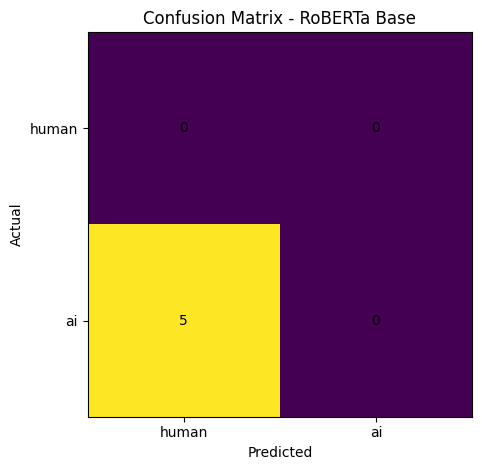

In [29]:
evaluate("RoBERTa Base", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_roberta)))

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.80      0.89         5

    accuracy                           0.80         5
   macro avg       0.50      0.40      0.44         5
weighted avg       1.00      0.80      0.89         5


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.200


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

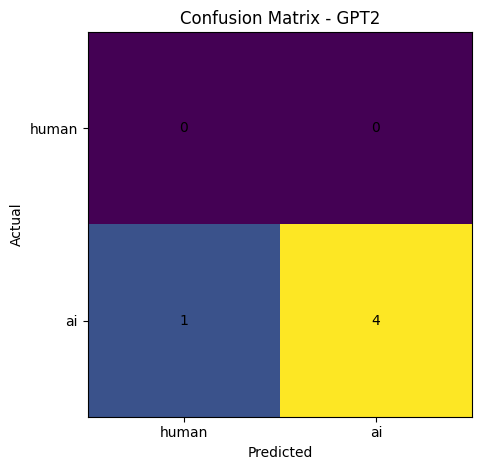

In [30]:
evaluate("GPT2", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_ppl)))

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      1.00      1.00         5

    accuracy                           1.00         5
   macro avg       0.50      0.50      0.50         5
weighted avg       1.00      1.00      1.00         5


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.000


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to contro

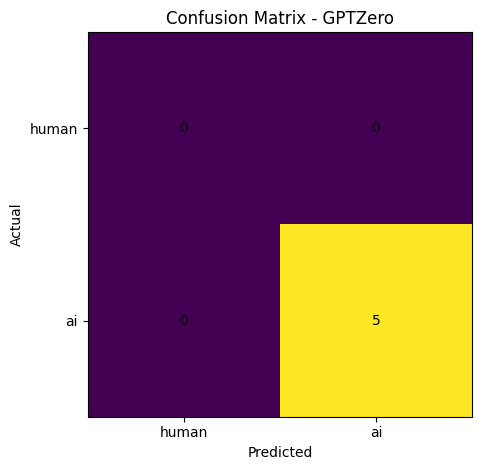

In [31]:
evaluate("GPTZero", ["ai"] * len(new_generated_texts), ["ai", "ai", "ai", "ai", "ai"])